In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

working_dir = 'F:\Projects\Ask2.ai\Diffusion'
os.chdir(working_dir)
sns.set_style('whitegrid')

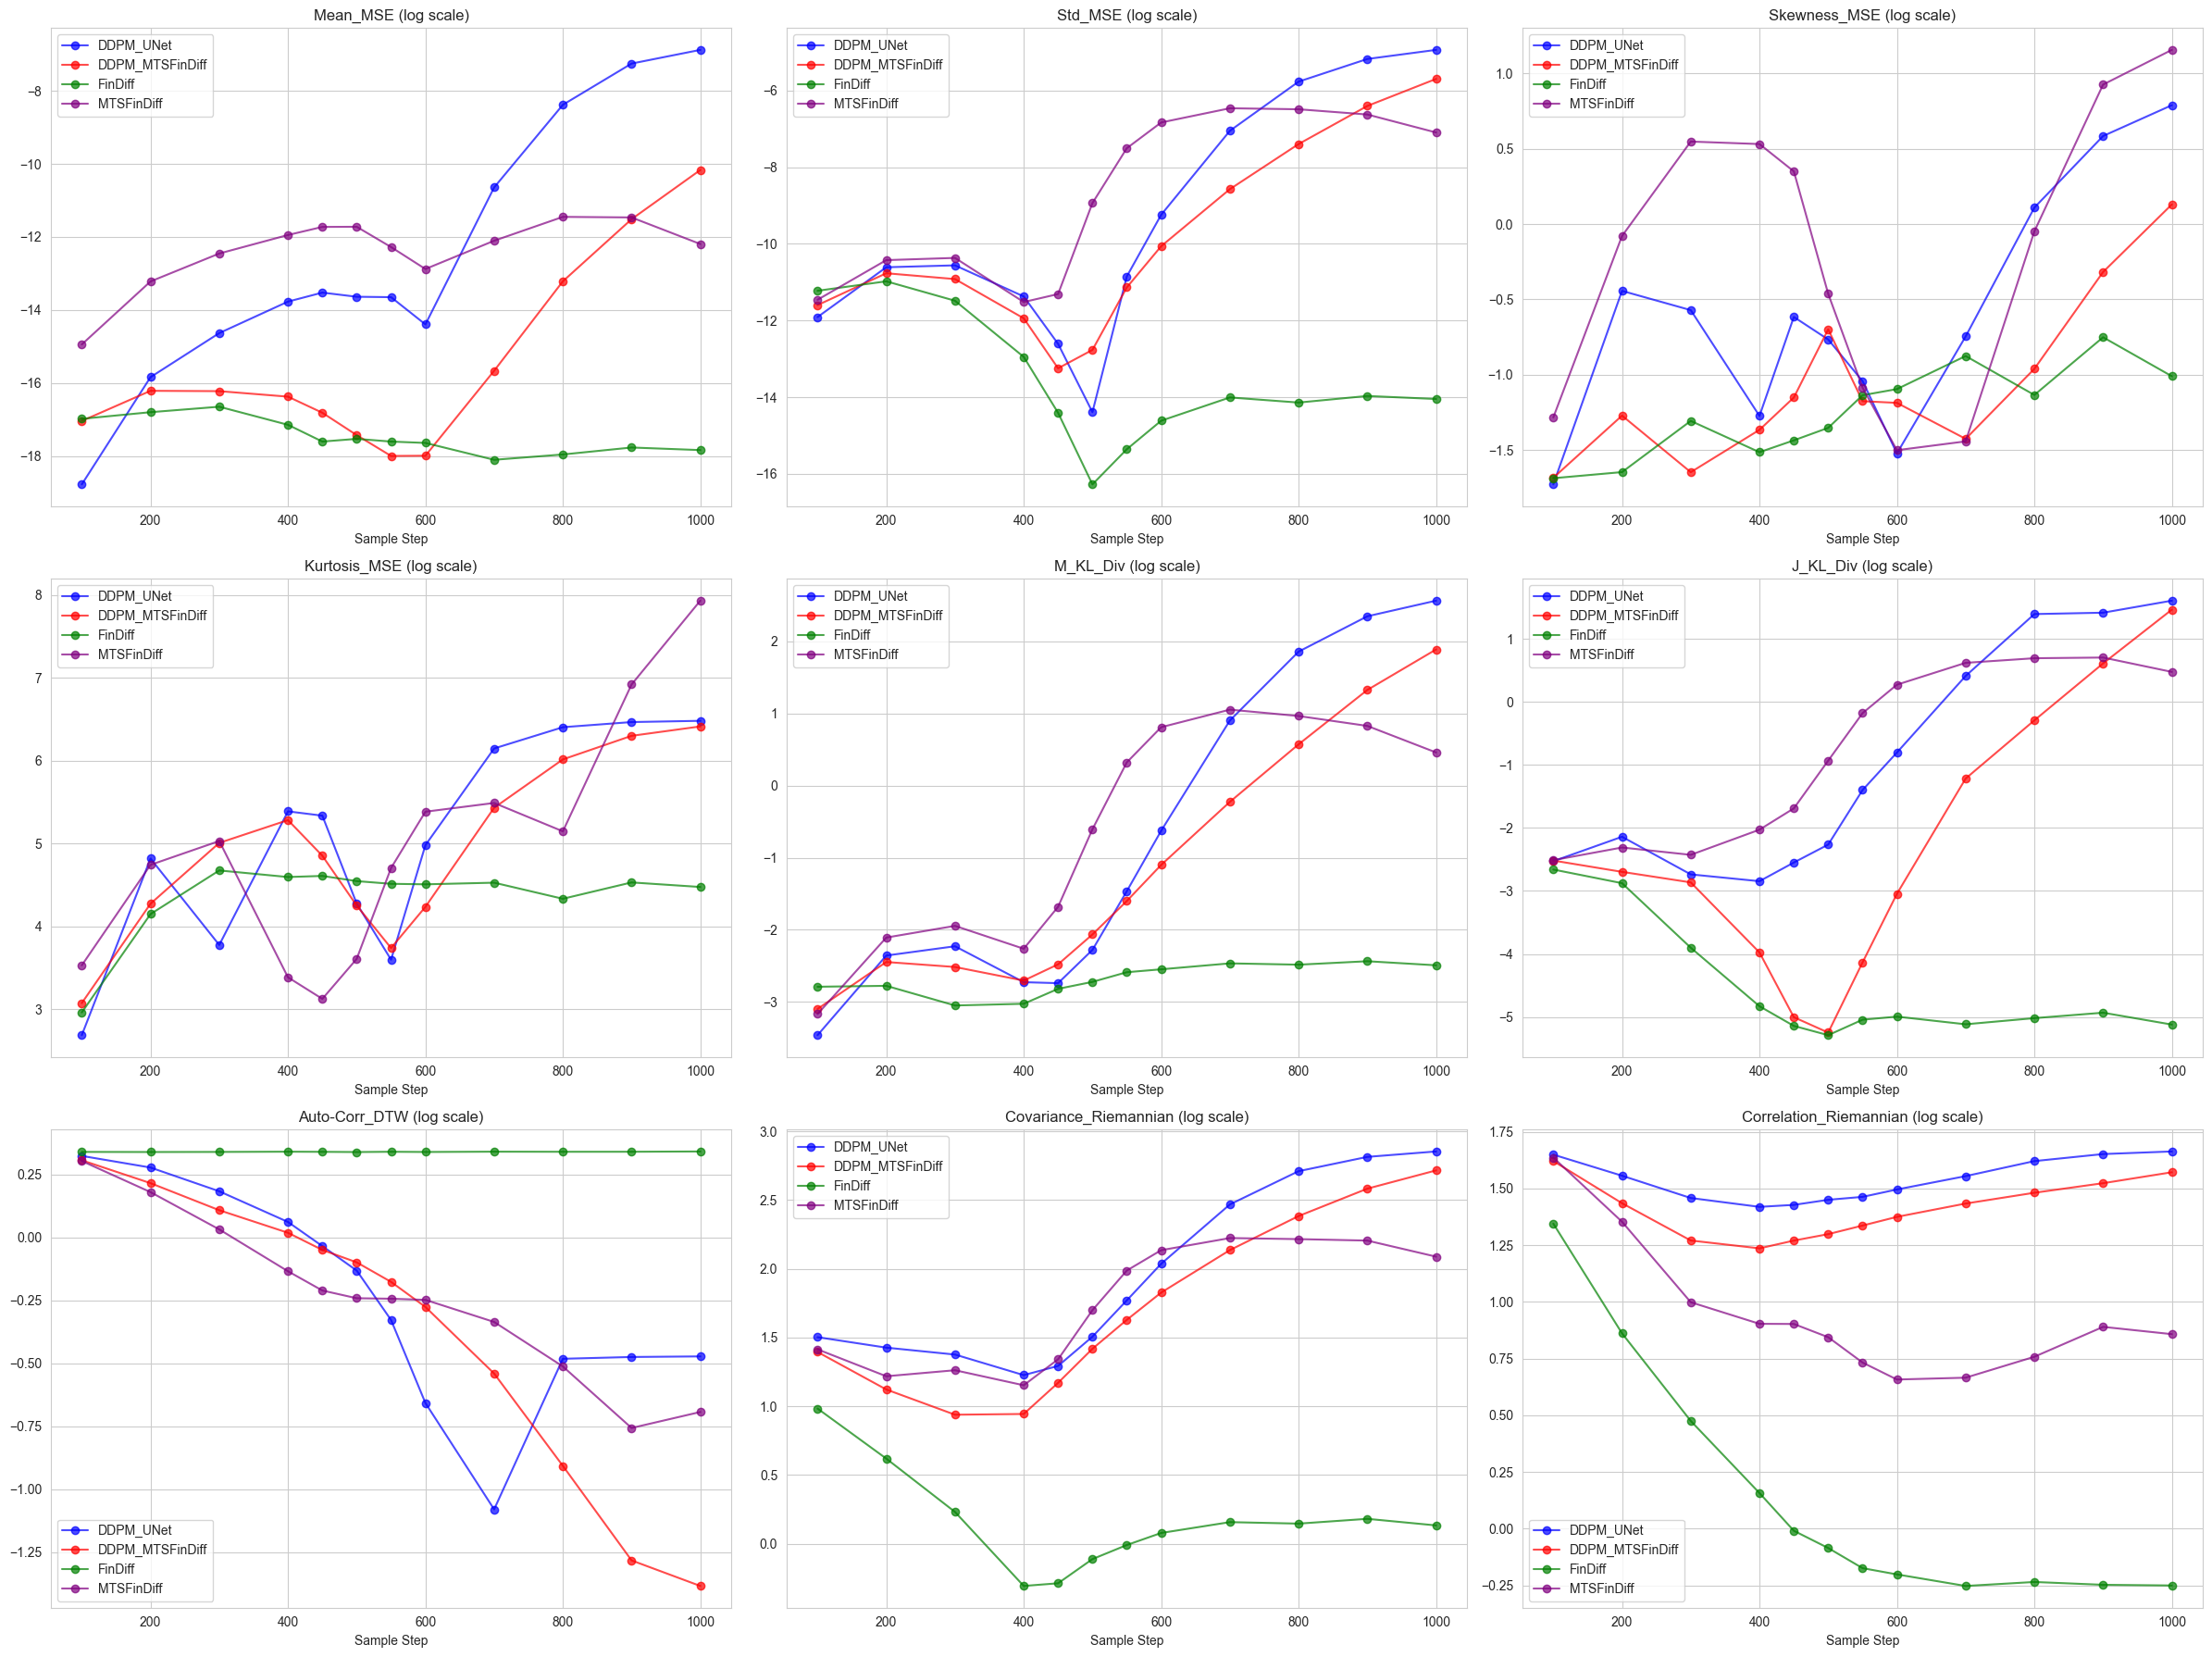

In [10]:
csv_files = [
    "./comparison_results/DDPM_UNet.csv",
    "./comparison_results/DDPM_MTSFinDiff.csv",
    "./comparison_results/FinDiff.csv",
    "./comparison_results/MTSFinDiff.csv",
]

names = ['DDPM_UNet', 'DDPM_MTSFinDiff', 'FinDiff', 'MTSFinDiff']

# Read each CSV into a DataFrame
dataframes = [pd.read_csv(f) for f in csv_files]

# Convert each DataFrame to a dictionary of lists for easy plotting (similar to your original structure)
results_dicts = [df.to_dict(orient='list') for df in dataframes]

# Identify the metrics (all columns except 'Step')
metrics = [col for col in dataframes[0].columns if col != 'Step']

# Layout for subplots
num_plots = len(metrics)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols  # round up

# Create figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 8, num_rows * 6))
axes = axes.flatten()

# Choose some distinct colors for up to four models
colors = ['blue', 'red', 'green', 'purple']

# Plot each metric in its own subplot, looping over the 4 models
for idx, metric_name in enumerate(metrics):
    ax = axes[idx]
    for i, results in enumerate(results_dicts):
        ax.plot(
            results['Step'], 
            np.log(results[metric_name]),
            marker='o',
            linestyle='-',
            color=colors[i % len(colors)],
            alpha=0.7,
            label=names[i]  # Or use a more descriptive label
        )
    ax.set_title(metric_name + ' (log scale)')
    ax.set_xlabel('Sample Step')
    ax.grid(True)
    ax.legend()

# If the number of metrics is not a multiple of num_cols, remove extra axes
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('./comparison_results/results_comparison.png', dpi=300)
plt.show()

In [11]:
# Extract the row where Step == 450 from each DataFrame
rows_450 = [df.loc[df['Step'] == 450].squeeze() for df in dataframes]

# Build a new DataFrame that has:
# - One row per metric
# - One column per model
# We skip the 'Step' column so we only show the metrics.
metrics = dataframes[0].columns.drop("Step")
table_data = {
    "Metric": metrics
}
for label, row in zip(names, rows_450):
    table_data[label] = row.loc[metrics].values

results_table = pd.DataFrame(table_data)
results_table.set_index("Metric", inplace=True)

# Now 'results_table' has rows = all metrics, columns = [model1, model2, model3, model4].
# For example, print it to console:
print(results_table)

                         DDPM_UNet  DDPM_MTSFinDiff       FinDiff  MTSFinDiff
Metric                                                                       
Mean_MSE                  0.000001     5.005741e-08  2.275560e-08    0.000008
Std_MSE                   0.000003     1.767569e-06  5.533954e-07    0.000012
Skewness_MSE              0.540153     3.166783e-01  2.384199e-01    1.417565
Kurtosis_MSE            207.988362     1.282230e+02  1.004826e+02   22.781205
M_KL_Div                  0.064677     8.394839e-02  5.978256e-02    0.186263
J_KL_Div                  0.078179     6.727074e-03  5.859576e-03    0.184536
Auto-Corr_DTW             0.966527     9.519283e-01  1.405844e+00    0.810139
Covariance_Riemannian     3.646179     3.224797e+00  7.503095e-01    3.826892
Correlation_Riemannian    4.169192     3.562105e+00  9.912403e-01    2.466422


In [15]:
results_table.to_latex(index=True, float_format="%.4g")

'\\begin{tabular}{lrrrr}\n\\toprule\n & DDPM_UNet & DDPM_MTSFinDiff & FinDiff & MTSFinDiff \\\\\nMetric &  &  &  &  \\\\\n\\midrule\nMean_MSE & 1.341e-06 & 5.006e-08 & 2.276e-08 & 8.088e-06 \\\\\nStd_MSE & 3.344e-06 & 1.768e-06 & 5.534e-07 & 1.225e-05 \\\\\nSkewness_MSE & 0.5402 & 0.3167 & 0.2384 & 1.418 \\\\\nKurtosis_MSE & 208 & 128.2 & 100.5 & 22.78 \\\\\nM_KL_Div & 0.06468 & 0.08395 & 0.05978 & 0.1863 \\\\\nJ_KL_Div & 0.07818 & 0.006727 & 0.00586 & 0.1845 \\\\\nAuto-Corr_DTW & 0.9665 & 0.9519 & 1.406 & 0.8101 \\\\\nCovariance_Riemannian & 3.646 & 3.225 & 0.7503 & 3.827 \\\\\nCorrelation_Riemannian & 4.169 & 3.562 & 0.9912 & 2.466 \\\\\n\\bottomrule\n\\end{tabular}\n'

# EI

In [2]:
import math

def z_calc(cols: list, data: pd.DataFrame, alpha=0.05):
    z_alpha = []
    z_1_alpha = []
    for col in cols:
        z_alpha.append(np.percentile(data[col], 100 * alpha))
        z_1_alpha.append(np.percentile(data[col], 100 * (1 - alpha)))
    return z_alpha, z_1_alpha

def EI_calc(cols: list, data: pd.DataFrame, alpha=0.05, w=None):
    x_alpha = -math.log((1 - alpha)/alpha)
    a = -x_alpha
    z_alpha, z_1_alpha = z_calc(cols, data, alpha)
    beta = []
    for i in range(len(cols)):
        beta.append(2 * a/(z_1_alpha[i] - z_alpha[i]))
    
    m_hat = beta * (data[cols] - z_alpha) - a
    m_tilda = 1 / (1 + np.exp(-m_hat))
    
    if w is None:
        w = [1/len(cols)] * len(cols)
    else:
        w = w / np.sum(w)
    EI = np.sqrt(np.sum(w * m_tilda**2, axis=1)) / np.sqrt(np.sum(w))
    
    return EI

In [3]:
csv_files = [
    "./comparison_results/DDPM_UNet.csv",
    "./comparison_results/DDPM_MTSFinDiff.csv",
    "./comparison_results/FinDiff.csv",
    "./comparison_results/MTSFinDiff.csv",
]

names = ['DDPM_UNet', 'DDPM_MTSFinDiff', 'FinDiff', 'MTSFinDiff']

# Read each CSV into a DataFrame
dataframes = [pd.read_csv(f) for f in csv_files]
num_rows = len(dataframes[0])
names_col = [names[0]] * num_rows + [names[1]] * num_rows + [names[2]] * num_rows + [names[3]] * num_rows
df_results = pd.concat(dataframes)
df_results.insert(0, 'Model', names_col)
"""cols = ['Mean_MSE', 'Std_MSE', 'Skewness_MSE', 'Kurtosis_MSE',
        'M_KL_Div', 'J_KL_Div', 'Auto-Corr_DTW', 'Covariance_Riemannian',
        'Correlation_Riemannian']"""
cols = ['M_KL_Div', 'Auto-Corr_DTW', 'Correlation_Riemannian']
df_results.iloc[:, 2:] = df_results.iloc[:, 2:].apply(np.log)

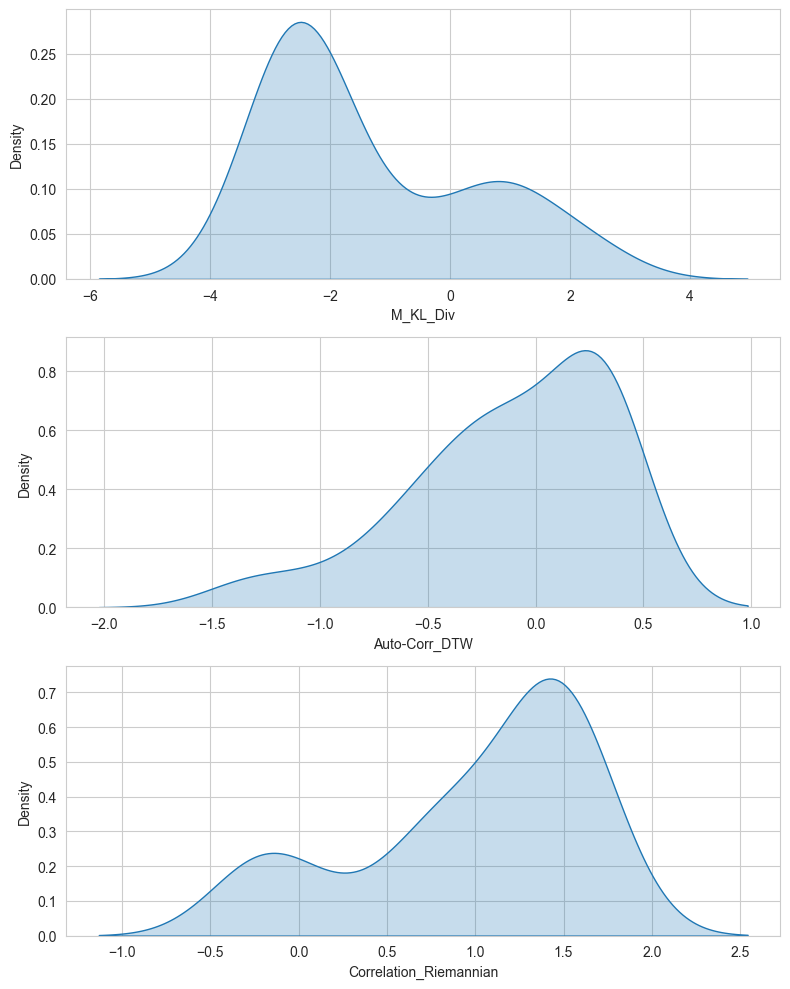

In [4]:
# plot distribution of columns
fig, axs = plt.subplots(len(cols), 1, figsize=(8, 10))
for i, col in enumerate(cols):
    sns.kdeplot(df_results[col], fill=True, ax=axs[i])

plt.tight_layout()    
plt.show()

In [5]:
EI = EI_calc(cols, df_results, alpha=0.1, w = [0.3, 0.4, 0.3])
df_results['EI'] = EI

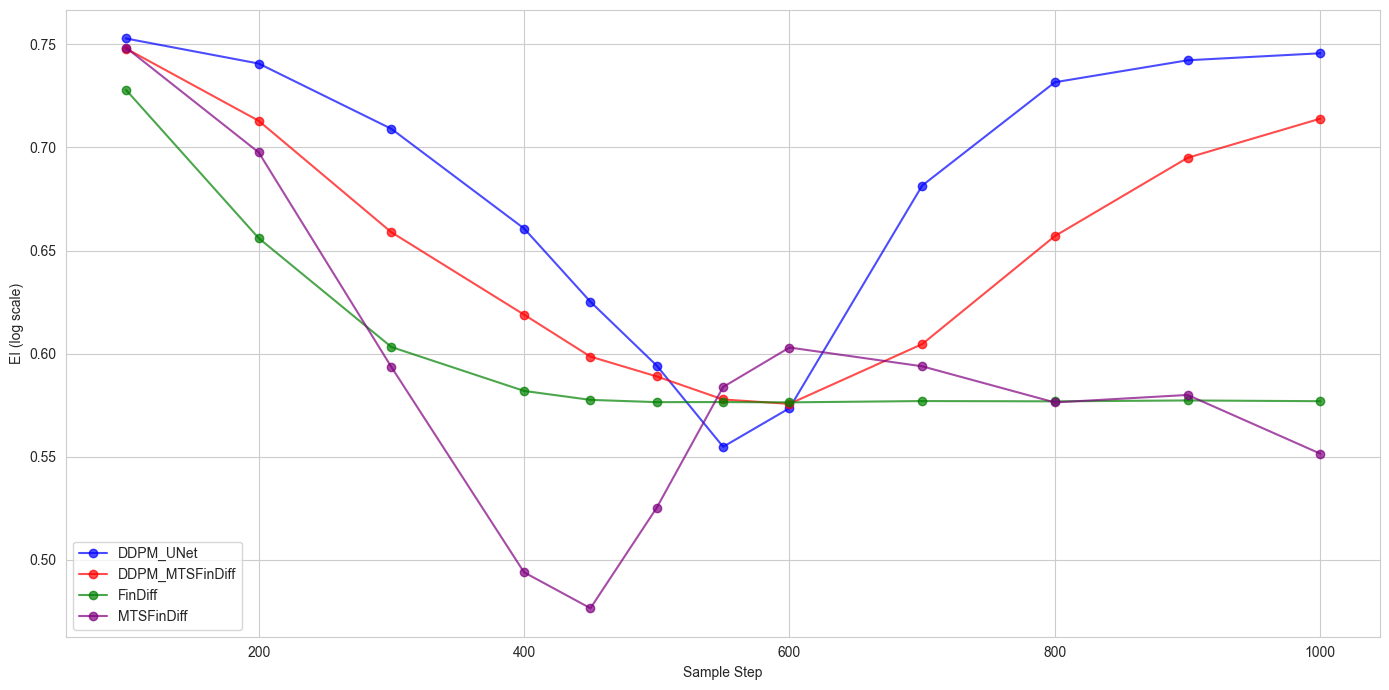

In [6]:
plt.figure(figsize=(14, 7))
colors = ['blue', 'red', 'green', 'purple']

for i, name in enumerate(names):
    data = df_results[df_results['Model'] == name]
    plt.plot(data['Step'], 
             data['EI'],
             marker='o',
             linestyle='-',
             alpha=0.7,
             label=name,
             color=colors[i])
    
plt.xlabel('Sample Step')
plt.ylabel('EI (log scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('./comparison_results/EI_comparison.png', dpi=300)
plt.show()

In [40]:
df_results

,Model,Step,Mean_MSE,Std_MSE,Skewness_MSE,Kurtosis_MSE,M_KL_Div,J_KL_Div,Auto-Corr_DTW,Covariance_Riemannian,Correlation_Riemannian,EI
0,DDPM_UNet,100,-18.770331,-11.909570,-1.725571,2.687774,-3.458949,-2.527704,0.324408,1.502974,1.649283,0.801115
1,DDPM_UNet,200,-15.835873,-10.610548,-0.443128,4.819520,-2.355807,-2.139959,0.278168,1.426814,1.556334,0.804416
2,DDPM_UNet,300,-14.630794,-10.560900,-0.570719,3.776691,-2.227123,-2.736833,0.183831,1.376493,1.458007,0.764547
3,DDPM_UNet,400,-13.768978,-11.371942,-1.271881,5.389188,-2.724803,-2.844780,0.061896,1.226847,1.418993,0.736023
4,DDPM_UNet,450,-13.522368,-12.608464,-0.615903,5.337482,-2.738357,-2.548748,-0.034046,1.293680,1.427722,0.722720
5,DDPM_UNet,500,-13.636284,-14.389118,-0.765245,4.276575,-2.277637,-2.264149,-0.131263,1.506654,1.450111,0.708490
6,DDPM_UNet,550,-13.647327,-10.849746,-1.041010,3.598831,-1.464160,-1.399310,-0.327713,1.770712,1.463093,0.698522
7,DDPM_UNet,600,-14.392923,-9.241568,-1.520186,4.981342,-0.626856,-0.803847,-0.657727,2.036827,1.495656,0.686326
8,DDPM_UNet,700,-10.644051,-7.051643,-0.745043,6.148578,0.900732,0.410202,-1.080429,2.468555,1.554495,0.743832
9,DDPM_UNet,800,-8.383267,-5.769376,0.108828,6.405199,1.854700,1.391734,-0.481910,2.710509,1.620751,0.799953
